In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import scipy.sparse as sp
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import pickle

print("All libraries imported!")

All libraries imported!


Data load

In [3]:


df1 = pd.read_csv("songs/spotify_data clean.csv")
df2 = pd.read_csv("songs/track_data_final.csv")

print(df1.shape)
print(df2.shape)

(8582, 15)
(8778, 15)


In [4]:
print(df1.head())
print(df2.head())

                 track_id                                       track_name  \
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2  7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3  67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4  15xptTfRBrjsppW0INUZjf                            ride me like a harley   

   track_number  track_popularity  explicit artist_name  artist_popularity  \
0             4                 0      True       Diplo                 77   
1             1                 0      True    Yelawolf                 64   
2             1                 4      True   Riff Raff                 48   
3             8                30      True       Diplo                 77   
4             2                 0      True     Rumelis                 48   

   artist_followers                      artist_genres  \
0   

Cleaning

In [5]:
# df1 ko df convert
df = df1.copy()
print(df.shape)

(8582, 15)


In [6]:
# 1. Missing genres fill 
df['artist_genres'] = df['artist_genres'].fillna('unknown')

# 2. Duration outliers drop
df = df[(df['track_duration_min'] >= 0.5) & (df['track_duration_min'] <= 8)]

# 3. Missing artist_name rows drop 
df = df.dropna(subset=['artist_name'])

print(df.shape)  # Should be ~8,530 rows

(8531, 15)


features

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(tokenizer=lambda x: [g.strip() for g in x.split(',')])
genre_matrix = vectorizer.fit_transform(df['artist_genres'])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


 similarity
 

In [8]:
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

numeric_sparse = sp.csr_matrix(df[numeric_cols].values)
feature_matrix = sp.hstack([numeric_sparse, genre_matrix])

similarity = cosine_similarity(feature_matrix)
print("Done! Shape:", similarity.shape)

Done! Shape: (8531, 8531)


 recommender function
 

In [9]:
def recommend_songs(song_name, n=5):
    matches = df[df['track_name'].str.lower() == song_name.lower()]
    if matches.empty:
        print(f"'{song_name}' nahi mila!")
        return
    
    idx = matches.index[0]
    position = df.index.get_loc(idx)
    
    sim_scores = sorted(enumerate(similarity[position]), key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    song_indices = [i[0] for i in sim_scores]
    result = df.iloc[song_indices][['track_name', 'artist_name', 'artist_genres', 'track_popularity']]
    print(f"\n'{song_name}' jaisi {n} songs:\n")
    print(result.to_string(index=False))

# Test karo
recommend_songs("Blinding Lights")


'Blinding Lights' jaisi 5 songs:

               track_name artist_name                               artist_genres  track_popularity
                Heartless  The Weeknd r&b pop, alternative r&b, hip hop, synthpop          0.434343
          Save Your Tears  The Weeknd r&b pop, alternative r&b, hip hop, synthpop          0.454545
Family (with Suzanna Son)  The Weeknd r&b pop, alternative r&b, hip hop, synthpop          0.393939
         Call Out My Name  The Weeknd r&b pop, alternative r&b, hip hop, synthpop          0.464646
            Rolling Stone  The Weeknd r&b pop, alternative r&b, hip hop, synthpop          0.484848


 EDA visualizations 
 

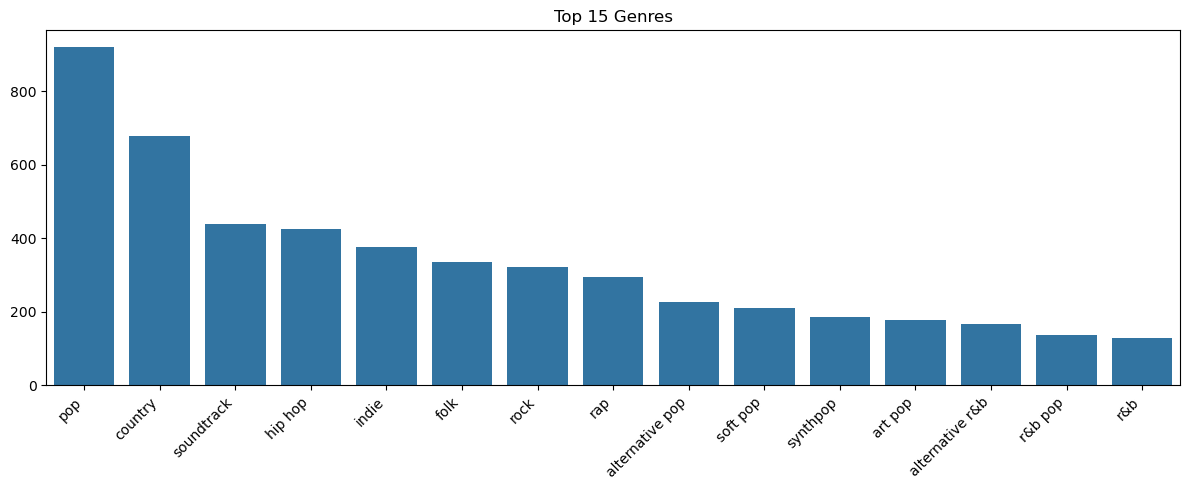

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

all_genres = []
for g in df['artist_genres']:
    all_genres.extend([x.strip() for x in g.split(',')])

genre_counts = Counter(all_genres).most_common(16)
genre_counts_filtered = [(g, c) for g, c in genre_counts if g != 'unknown'][:15]
genres, counts = zip(*genre_counts_filtered)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(genres), y=list(counts))
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Genres")
plt.tight_layout()
plt.show()

In [11]:
# Unknown genre wale tracks  drop 
df = df[df['artist_genres'] != 'unknown']
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 5181


In [12]:
df = df.reset_index(drop=True)
print("Index reset done:", df.shape)

Index reset done: (5181, 15)


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer

# Numeric normalize
scaler = MinMaxScaler()
numeric_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Genre vectorize
vectorizer = CountVectorizer(tokenizer=lambda x: [g.strip() for g in x.split(',')])
genre_matrix = vectorizer.fit_transform(df['artist_genres'])

print("Genre matrix shape:", genre_matrix.shape)

Genre matrix shape: (5181, 430)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [14]:
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

numeric_sparse = sp.csr_matrix(df[numeric_cols].values)
feature_matrix = sp.hstack([numeric_sparse, genre_matrix])

similarity = cosine_similarity(feature_matrix)
print("Similarity matrix ready! Shape:", similarity.shape)

Similarity matrix ready! Shape: (5181, 5181)


In [15]:
def recommend_songs(song_name, n=5):
    matches = df[df['track_name'].str.lower() == song_name.lower()]
    if matches.empty:
        print(f"'{song_name}' not found!")
        return
    
    idx = matches.index[0]
    position = df.index.get_loc(idx)
    
    sim_scores = sorted(enumerate(similarity[position]), key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    song_indices = [i[0] for i in sim_scores]
    result = df.iloc[song_indices][['track_name', 'artist_name', 'artist_genres', 'track_popularity']]
    print(f"\n'{song_name}' jaisi {n} songs:\n")
    print(result.to_string(index=False))
    

In [16]:

print(df['track_name'].sample(10).tolist())

['Holy (feat. Chance The Rapper)', 'Jolene', 'champagne problems', '4th of July', 'Toosie Slide', 'Burning Blue', 'All I Know', 'Wake Up in the Sky', 'White Mustang', '4 Morant (Better Luck Next Time)']


In [17]:
recommend_songs("Shape of You") 


'Shape of You' jaisi 5 songs:

track_name artist_name artist_genres  track_popularity
Bad Habits  Ed Sheeran      soft pop          0.828283
Photograph  Ed Sheeran      soft pop          0.868687
   Perfect  Ed Sheeran      soft pop          0.888889
   Shivers  Ed Sheeran      soft pop          0.818182
    Camera  Ed Sheeran      soft pop          0.797980


In [18]:
def recommend_songs(song_name, n=5):
    matches = df[df['track_name'].str.lower() == song_name.lower()]
    if matches.empty:
        print(f"'{song_name}' nahi mila!")
        return
    
    idx = matches.index[0]
    position = df.index.get_loc(idx)
    original_artist = df.loc[idx, 'artist_name']
    
    sim_scores = sorted(enumerate(similarity[position]), key=lambda x: x[1], reverse=True)
    
    # Same artist ke songs skip karo
    results = []
    for i, score in sim_scores[1:]:
        if df.iloc[i]['artist_name'] != original_artist:
            results.append(i)
        if len(results) == n:
            break
    
    result = df.iloc[results][['track_name', 'artist_name', 'artist_genres', 'track_popularity']]
    print(f"\n'{song_name}' jaisi {n} songs:\n")
    print(result.to_string(index=False))

# Test karo
recommend_songs("Shape of You")



'Shape of You' jaisi 5 songs:

          track_name artist_name artist_genres  track_popularity
          Easy On Me       Adele      soft pop          0.787879
          Easy On Me       Adele      soft pop          0.818182
 Rolling in the Deep       Adele      soft pop          0.797980
Set Fire to the Rain       Adele      soft pop          0.828283
           Oh My God       Adele      soft pop          0.727273


In [19]:
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

# Genre ko kam weight do (0.5x), numeric ko zyada (2x)
numeric_sparse = sp.csr_matrix(df[numeric_cols].values * 2)
genre_sparse = genre_matrix.astype(float) * 0.5

feature_matrix = sp.hstack([numeric_sparse, genre_sparse])
similarity = cosine_similarity(feature_matrix)
print("New similarity matrix ready!")

New similarity matrix ready!


In [20]:
recommend_songs("Shape of You")



'Shape of You' jaisi 5 songs:

                      track_name artist_name artist_genres  track_popularity
Send My Love (To Your New Lover)       Adele      soft pop          0.717172
                       Oh My God       Adele      soft pop          0.727273
                      Easy On Me       Adele      soft pop          0.787879
                    Can I Get It       Adele      soft pop          0.656566
             Rolling in the Deep       Adele      soft pop          0.797980


In [21]:

feature_matrix = sp.csr_matrix(df[numeric_cols].values)
similarity = cosine_similarity(feature_matrix)

recommend_songs("Shape of You")



'Shape of You' jaisi 5 songs:

                                             track_name   artist_name                         artist_genres  track_popularity
What Was I Made For? [From The Motion Picture Barbie"]" Billie Eilish alternative pop, electropop, dark pop          0.848485
                                    everything i wanted Billie Eilish alternative pop, electropop, dark pop          0.838384
                                                Opalite  Taylor Swift             country, pop, indie, folk          0.979798
                                             WILDFLOWER Billie Eilish alternative pop, electropop, dark pop          0.929293
       The Life of a Showgirl (feat. Sabrina Carpenter)  Taylor Swift             country, pop, indie, folk          0.939394


In [22]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(feature_matrix)

print("KNN Model trained!")

KNN Model trained!


model

In [23]:
def recommend_knn(song_name, n=5):
    # Quotes hataao
    song_name = song_name.strip().strip('"').strip("'")
    
    matches = df[df['track_name'].str.lower() == song_name.lower()]
    if matches.empty:
        print(f"'{song_name}' nahi mila!")
        return
    
    idx = matches.index[0]
    song_vector = feature_matrix[idx]
    
    distances, indices = knn_model.kneighbors(song_vector, n_neighbors=n+1)
    
    song_indices = indices[0][1:]
    result = df.iloc[song_indices][['track_name', 'artist_name', 'artist_genres', 'track_popularity']]
    print(f"\n'{song_name}' jaisi {n} songs:\n")
    print(result.to_string(index=False))

In [24]:
def recommend_knn(song_name, n=5):
    matches = df[df['track_name'].str.lower() == song_name.lower()]
    if matches.empty:
        print(f"'{song_name}' nahi mila!")
        return
    
    idx = matches.index[0]
    song_vector = feature_matrix[idx]
    
    distances, indices = knn_model.kneighbors(song_vector, n_neighbors=n+1)
    
    song_indices = indices[0][1:]
    result = df.iloc[song_indices][['track_name', 'artist_name', 'artist_genres', 'track_popularity']]
    print(f"\n'{song_name}' jaisi {n} songs:\n")
    print(result.to_string(index=False))

In [25]:
recommend_knn("Shape of You")


'Shape of You' jaisi 5 songs:

                                             track_name   artist_name                         artist_genres  track_popularity
What Was I Made For? [From The Motion Picture Barbie"]" Billie Eilish alternative pop, electropop, dark pop          0.848485
                                             Bad Habits    Ed Sheeran                              soft pop          0.828283
                                             Photograph    Ed Sheeran                              soft pop          0.868687
                                    everything i wanted Billie Eilish alternative pop, electropop, dark pop          0.838384
                                                Perfect    Ed Sheeran                              soft pop          0.888889


 Model Save

In [26]:
import pickle

with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

with open('df.pkl', 'wb') as f:
    pickle.dump(df, f)

with open('feature_matrix.pkl', 'wb') as f:
    pickle.dump(feature_matrix, f)

print("Model saved!")

Model saved!


In [27]:
pip install ipywidgets


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:

print(df['track_name'].sample(20).tolist())



["Sugar, We're Going Down", 'twilight zone', "I'm Scum", 'ONE CALL', 'Guess featuring billie eilish', 'Wild', 'B.O.B. - Bombs Over Baghdad', 'Heaven', 'The Fellowship (From The Lord of the Rings: The Fellowship of the Ring")"', 'Cheers (Drink To That)', 'In Noctem', 'Ransom', 'Sports car', 'shaklekmagnona', 'Elet El Noum', 'Third Date', 'Vegetable', 'Dragon Warrior Is Among Us', 'Headlights', 'Future Days']


In [29]:
df = df.reset_index(drop=True)

with open('df.pkl', 'wb') as f:
    pickle.dump(df, f)

with open('feature_matrix.pkl', 'wb') as f:
    pickle.dump(feature_matrix, f)

with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

print("Re-saved successfully!")
print(f"Total songs: {len(df)}")

# Check karo Shape of You hai ya nahi
check = df[df['track_name'].str.lower() == 'shape of you']
print(f"Shape of You found: {len(check)} times")

Re-saved successfully!
Total songs: 5181
Shape of You found: 2 times


In [30]:
import ipywidgets as widgets
from IPython.display import display, clear_output

song_dropdown = widgets.Combobox(
    placeholder='write the name of song...',
    options=list(df['track_name'].values),
    description='Song:',
    layout=widgets.Layout(width='400px')
)

n_slider = widgets.IntSlider(
    value=5, min=1, max=10,
    description='Results:',
    layout=widgets.Layout(width='400px')
)

btn = widgets.Button(
    description='Recommend ',
    button_style='success',
    layout=widgets.Layout(width='200px')
)

output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        recommend_knn(song_dropdown.value, n_slider.value)

btn.on_click(on_click)

display(song_dropdown, n_slider, btn, output)

Combobox(value='', description='Song:', layout=Layout(width='400px'), options=('Trippy Mane (ft. Project Pat)'…

IntSlider(value=5, description='Results:', layout=Layout(width='400px'), max=10, min=1)

Button(button_style='success', description='Recommend ', layout=Layout(width='200px'), style=ButtonStyle())

Output()

In [31]:
print(df.columns.tolist())
print(df.head(2))


['track_id', 'track_name', 'track_number', 'track_popularity', 'explicit', 'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres', 'album_id', 'album_name', 'album_release_date', 'album_total_tracks', 'album_type', 'track_duration_min']
                 track_id                     track_name  track_number  \
0  3EJS5LyekDim1Tf5rBFmZl  Trippy Mane (ft. Project Pat)             4   
1  1oQW6G2ZiwMuHqlPpP27DB                           OMG!             1   

   track_popularity  explicit artist_name  artist_popularity  \
0               0.0      True       Diplo           0.765306   
1               0.0      True    Yelawolf           0.632653   

   artist_followers                      artist_genres  \
0          0.019326                         moombahton   
1          0.016239  country hip hop, southern hip hop   

                 album_id          album_name album_release_date  \
0  5QRFnGnBeMGePBKF2xTz5z  d00mscrvll, Vol. 1         2025-10-31   
1  4SUmmwnv0xTjRcLd

In [32]:
def assign_mood(genre):
    genre = str(genre).lower()
    
    if any(word in genre for word in ['sad', 'emo', 'grief', 'blues', 'heartbreak', 'melancholy', 
                                       'dark', 'depressing', 'tragic', 'dramatic', 'doom', 
                                       'gothic', 'mourning', 'sorrow', 'mournful']):
        return 'sad'
    elif any(word in genre for word in ['sleep', 'ambient', 'classical', 'instrumental', 
                                         'piano', 'orchestra', 'meditation', 'healing',
                                         'peaceful', 'lullaby', 'new age', 'soundtrack']):
        return 'calm'
    elif any(word in genre for word in ['party', 'dance', 'edm', 'electro', 'club', 
                                         'house', 'techno', 'disco', 'rave', 'dj']):
        return 'party'
    elif any(word in genre for word in ['workout', 'hip hop', 'rap', 'trap', 'drill',
                                         'hype', 'moombahton', 'bounce', 'grime']):
        return 'energetic'
    elif any(word in genre for word in ['romantic', 'love', 'r&b', 'soul', 'smooth',
                                         'wedding', 'sensual', 'bedroom']):
        return 'romantic'
    elif any(word in genre for word in ['chill', 'lofi', 'lo-fi', 'chillhop', 
                                         'easy listening', 'soft', 'acoustic', 'mellow']):
        return 'chill'
    elif any(word in genre for word in ['rock', 'metal', 'punk', 'grunge', 
                                         'hardcore', 'rage', 'aggressive', 'thrash']):
        return 'angry'
    elif any(word in genre for word in ['pop', 'indie', 'folk', 'country', 'happy',
                                         'feel good', 'upbeat', 'fun', 'cheerful']):
        return 'happy'
    else:
        return 'happy'

df['mood'] = df['artist_genres'].apply(assign_mood)
print(df['mood'].value_counts())

mood
happy        1680
energetic    1060
angry         565
calm          494
sad           381
chill         375
party         347
romantic      279
Name: count, dtype: int64


C:\Users\yasha\AppData\Local\Temp\ipykernel_21340\542122152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mood', data=df, palette='Set2', order=df['mood'].value_counts().index)


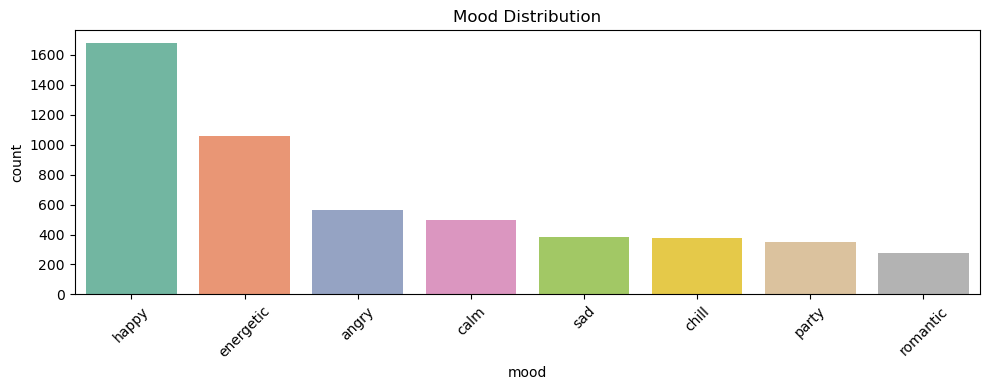

In [33]:
plt.figure(figsize=(10, 4))
sns.countplot(x='mood', data=df, palette='Set2', order=df['mood'].value_counts().index)
plt.title("Mood Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features prepare karo
vectorizer_mood = CountVectorizer(tokenizer=lambda x: [g.strip() for g in x.split(',')])
X_genre = vectorizer_mood.fit_transform(df['artist_genres'])

# Numeric features add karo
numeric = sp.csr_matrix(df[['track_popularity', 'artist_popularity', 'artist_followers']].values)
X = sp.hstack([X_genre, numeric])
y = df['mood']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", rf_model.score(X_test, y_test))
print("\nReport:\n", classification_report(y_test, y_train_pred := rf_model.predict(X_test)))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy: 0.9807135969141755

Report:
               precision    recall  f1-score   support

       angry       0.99      0.97      0.98        98
        calm       1.00      0.98      0.99        81
       chill       1.00      1.00      1.00        82
   energetic       1.00      0.97      0.98       207
       happy       0.95      1.00      0.97       344
       party       1.00      0.93      0.96        80
    romantic       0.98      1.00      0.99        62
         sad       1.00      0.98      0.99        83

    accuracy                           0.98      1037
   macro avg       0.99      0.98      0.98      1037
weighted avg       0.98      0.98      0.98      1037



In [42]:
def assign_mood(genre):
    genre = str(genre).lower()
    
    # Sad - highest priority
    if any(word in genre for word in [
        'sad', 'emo', 'grief', 'blues', 'heartbreak', 'melancholy',
        'dark r&b', 'dark pop', 'doomscroll', 'doom', 'gothic',
        'mourning', 'sorrow', 'mournful', 'depressing', 'tragic',
        'dramatic', 'corrido', 'sad sierreno', 'cumbia sonidera']):
        return 'sad'
    
    # Calm
    elif any(word in genre for word in [
        'ambient', 'classical', 'instrumental', 'piano', 'orchestra',
        'meditation', 'healing', 'peaceful', 'lullaby', 'new age',
        'soundtrack', 'sleep', 'nature', 'spiritual', 'devotional',
        'worship', 'gospel', 'hymn', 'chant', 'mantra']):
        return 'calm'
    
    # Party
    elif any(word in genre for word in [
        'party', 'dance', 'edm', 'electro', 'club', 'house',
        'techno', 'disco', 'rave', 'dj', 'dancehall', 'dembow',
        'reggaeton', 'cumbia', 'afrobeats', 'afroswing']):
        return 'party'
    
    # Energetic
    elif any(word in genre for word in [
        'hip hop', 'rap', 'trap', 'drill', 'hype', 'moombahton',
        'bounce', 'grime', 'hardstyle', 'dubstep', 'phonk',
        'nu metal', 'alternative metal']):
        return 'energetic'
    
    # Romantic
    elif any(word in genre for word in [
        'r&b', 'soul', 'smooth', 'wedding', 'sensual', 'bedroom',
        'quiet storm', 'neo soul', 'contemporary r&b', 'love']):
        return 'romantic'
    
    # Chill
    elif any(word in genre for word in [
        'chill', 'lofi', 'lo-fi', 'chillhop', 'easy listening',
        'soft pop', 'mellow', 'acoustic', 'singer-songwriter',
        'indie folk', 'dream pop', 'shoegaze', 'chillwave']):
        return 'chill'
    
    # Angry
    elif any(word in genre for word in [
        'metal', 'punk', 'grunge', 'hardcore', 'thrash',
        'death metal', 'black metal', 'post-grunge', 'noise rock']):
        return 'angry'
    
    # Happy
    elif any(word in genre for word in [
        'pop', 'indie pop', 'synth pop', 'power pop', 'bubblegum',
        'k-pop', 'j-pop', 'c-pop', 'country', 'folk', 'bluegrass',
        'indie', 'alternative pop', 'art pop']):
        return 'happy'
    
    else:
        return 'chill'  # default chill - happy nahi

df['mood'] = df['artist_genres'].apply(assign_mood)
print(df['mood'].value_counts())

mood
happy        1453
energetic    1077
chill         798
calm          498
party         463
sad           358
romantic      277
angry         257
Name: count, dtype: int64


In [43]:
def genre_tokenizer(text):
    return [g.strip() for g in text.split(',')]

vectorizer_mood = CountVectorizer(tokenizer=genre_tokenizer)
X_genre = vectorizer_mood.fit_transform(df['artist_genres'])
numeric = sp.csr_matrix(df[['track_popularity', 'artist_popularity', 'artist_followers']].values)
X = sp.hstack([X_genre, numeric])
y = df['mood']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Accuracy:", rf_model.score(X_test, y_test))
print(df['mood'].value_counts())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy: 0.9720347155255545
mood
happy        1453
energetic    1077
chill         798
calm          498
party         463
sad           358
romantic      277
angry         257
Name: count, dtype: int64


In [44]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('vectorizer_mood.pkl', 'wb') as f:
    pickle.dump(vectorizer_mood, f)
df.to_pickle('df_with_mood.pkl')
print("Saved!")

Saved!


In [38]:
# Notebook mein yeh chalao
print("RF Model classes:", rf_model.classes_)
print("Total songs per mood:")
print(df['mood'].value_counts())



RF Model classes: ['angry' 'calm' 'chill' 'energetic' 'happy' 'party' 'romantic' 'sad']
Total songs per mood:
mood
happy        1680
energetic    1060
angry         565
calm          494
sad           381
chill         375
party         347
romantic      279
Name: count, dtype: int64


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def genre_tokenizer(text):
    return [g.strip() for g in text.split(',')]

vectorizer_mood = CountVectorizer(tokenizer=genre_tokenizer)
X_genre = vectorizer_mood.fit_transform(df['artist_genres'])

numeric = sp.csr_matrix(df[['track_popularity', 'artist_popularity', 'artist_followers']].values)
X = sp.hstack([X_genre, numeric])
y = df['mood']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Accuracy:", rf_model.score(X_test, y_test))
print(df['mood'].value_counts())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy: 0.9807135969141755
mood
happy        1680
energetic    1060
angry         565
calm          494
sad           381
chill         375
party         347
romantic      279
Name: count, dtype: int64


In [41]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('vectorizer_mood.pkl', 'wb') as f:
    pickle.dump(vectorizer_mood, f)

df.to_pickle('df_with_mood.pkl')

print("Saved!")

Saved!


In [45]:
print(df[df['mood'] == 'sad'].shape)
print(df['mood'].value_counts())
print(df[df['artist_genres'].str.contains('dark', case=False, na=False)]['mood'].value_counts())


(358, 16)
mood
happy        1453
energetic    1077
chill         798
calm          498
party         463
sad           358
romantic      277
angry         257
Name: count, dtype: int64
mood
sad      181
party     17
happy      4
chill      3
angry      1
Name: count, dtype: int64


In [46]:
# Sad songs ka mood check karo
sad_check = df[df['artist_genres'].str.contains('sad|blues|heartbreak|dark|emo', case=False, na=False)]
print(sad_check[['track_name', 'artist_genres', 'mood']].head(10))

                 track_name  artist_genres mood
3     ride me like a harley       dark r&b  sad
4                     BLEED       dark r&b  sad
5               come closer       dark r&b  sad
10      Eggshell Tap Dancer  pop punk, emo  sad
17  baby can you sin for me       dark r&b  sad
38     i don't need ur love       dark r&b  sad
65                   Psycho       dark r&b  sad
66            Rush From You       dark r&b  sad
70            Search Party!  pop punk, emo  sad
71                    CRAVE       dark r&b  sad


In [47]:
# Overall mood distribution
print(df['mood'].value_counts())

# Kuch sad genre songs ka mood check
print(df[df['mood']=='sad'][['track_name','artist_genres']].head(10))
print(df[df['mood']=='chill'][['track_name','artist_genres']].head(10))

mood
happy        1453
energetic    1077
chill         798
calm          498
party         463
sad           358
romantic      277
angry         257
Name: count, dtype: int64
                 track_name  artist_genres
3     ride me like a harley       dark r&b
4                     BLEED       dark r&b
5               come closer       dark r&b
10      Eggshell Tap Dancer  pop punk, emo
17  baby can you sin for me       dark r&b
38     i don't need ur love       dark r&b
65                   Psycho       dark r&b
66            Rush From You       dark r&b
70            Search Party!  pop punk, emo
71                    CRAVE       dark r&b
                            track_name                        artist_genres
18                                Amal                   sholawat, khaleeji
20                     Goodbye For Now                               hipdut
21     Here and Now (Where I Wanna Be)                             big room
31                        Wait For You          

In [52]:
mood_keywords = {
    'sad': ['sad songs', 'sad', 'cry', 'crying', 'depressed', 'heartbreak', 
            'broken heart', 'lonely', 'alone', 'tears', 'upset', 'grief', 
            'sorrow', 'dukhi', 'dard', 'dramatic', 'emotional', 'touching', 
            'teary', 'melancholy', 'painful', 'pain', 'miss', 'missing', 
            'breakup', 'tragedy', 'tragic'],
    'party': ['party songs', 'party', 'parties', 'club', 'clubbing', 'dance songs',
              'dance', 'dancing', 'dj', 'night out', 'celebration', 'banger', 
              'hype', 'nacho', 'floor', 'disco', 'rave', 'bash', 'groove'],
    'happy': ['happy songs', 'happy', 'fun', 'cheerful', 'joyful', 'good vibes', 
              'positive', 'upbeat', 'excited', 'khush', 'feel good', 'smile', 
              'joy', 'masti'],
    'chill': ['chill songs', 'chill', 'chilling', 'relax', 'relaxing', 'lazy', 
              'lofi', 'lo-fi', 'easy', 'slow', 'mellow', 'vibes', 'evening',
              'sunday', 'coffee', 'rainy day', 'background'],
    'romantic': ['romantic songs', 'romantic', 'romance', 'love songs', 'lover', 
                 'date', 'dating', 'crush', 'sweet', 'pyaar', 'ishq', 
                 'mohabbat', 'valentine', 'propose', 'wedding', 'couple'],
    'energetic': ['energetic songs', 'energetic', 'energy', 'workout songs', 
                  'workout', 'gym', 'running', 'exercise', 'pump', 'motivation', 
                  'motivated', 'hustle', 'rap songs', 'hip hop songs', 'beast', 
                  'power', 'fire', 'adrenaline'],
    'angry': ['angry songs', 'angry', 'anger', 'rage', 'mad', 'aggressive', 
              'rock songs', 'metal', 'punk', 'hardcore', 'gussa', 'frustrated', 
              'rebel'],
    'calm': ['calm songs', 'calm', 'calming', 'sleep songs', 'sleep', 'sleeping', 
             'study songs', 'study', 'studying', 'focus', 'meditation', 'meditate', 
             'ambient', 'instrumental', 'classical', 'piano', 'quiet', 'peaceful', 
             'neend', 'concentration', 'stress free', 'yoga', 'spa', 'nature',
             'devotional', 'devote', 'devoted', 'devotes', 'bhajan',
             'spiritual', 'prayer', 'mantra', 'worship', 'religious']
}

test = "sad songs"
txt = test.lower().strip()
for mood, keywords in mood_keywords.items():
    for kw in sorted(keywords, key=len, reverse=True):
        if kw in txt:
            print(f"Match found: '{kw}' -> {mood}")
            break

Match found: 'sad songs' -> sad


In [67]:
def assign_mood(genre):
    genre = str(genre).lower()
    
    if any(word in genre for word in [
        'sad', 'emo', 'grief', 'blues', 'heartbreak', 'melancholy',
        'dark r&b', 'dark pop', 'doom', 'gothic', 'mourning', 'sorrow',
        'mournful', 'depressing', 'tragic', 'dramatic', 'corrido',
        'sad sierreno', 'pop punk', 'folk rock', 'folk pop',
        'acoustic pop', 'indie folk', 'folk pop', 'soft pop',
        'singer-songwriter', 'sad indie', 'chamber pop']):
        return 'sad'
    
    elif any(word in genre for word in [
        'ambient', 'classical', 'instrumental', 'piano', 'orchestra',
        'meditation', 'healing', 'peaceful', 'lullaby', 'new age',
        'soundtrack', 'sleep', 'nature', 'spiritual', 'devotional',
        'worship', 'gospel', 'hymn', 'chant', 'mantra']):
        return 'calm'

    elif any(word in genre for word in [
        'party', 'dance', 'edm', 'electro', 'club', 'house',
        'techno', 'disco', 'rave', 'dj', 'dancehall', 'dembow',
        'reggaeton', 'cumbia', 'afrobeats', 'afroswing']):
        return 'party'

    elif any(word in genre for word in [
        'hip hop', 'rap', 'trap', 'drill', 'hype', 'moombahton',
        'bounce', 'grime', 'hardstyle', 'dubstep', 'phonk',
        'nu metal', 'alternative metal', 'urbano latino', 'trap latino']):
        return 'energetic'

    elif any(word in genre for word in [
        'r&b', 'soul', 'smooth', 'wedding', 'sensual', 'bedroom',
        'quiet storm', 'neo soul', 'contemporary r&b']):
        return 'romantic'

    elif any(word in genre for word in [
        'metal', 'punk', 'grunge', 'hardcore', 'thrash',
        'death metal', 'black metal', 'post-grunge', 'noise rock',
        'funk rock', 'alternative rock', 'hard rock', 'classic rock']):
        return 'angry'

    elif any(word in genre for word in [
        'chill', 'lofi', 'lo-fi', 'chillhop', 'easy listening',
        'mellow', 'chillwave', 'dream pop', 'shoegaze']):
        return 'chill'

    elif any(word in genre for word in [
        'synthpop', 'synth pop', 'art pop', 'k-pop', 'j-pop',
        'c-pop', 'indie pop', 'power pop', 'bubblegum',
        'country', 'bluegrass', 'pop rock']):
        return 'happy'

    else:
        return 'chill'

df['mood'] = df['artist_genres'].apply(assign_mood)
print(df['mood'].value_counts())

mood
energetic    1077
happy         972
chill         866
sad           682
calm          498
party         463
angry         347
romantic      276
Name: count, dtype: int64


In [68]:
vectorizer_mood = CountVectorizer(tokenizer=genre_tokenizer)
X_genre = vectorizer_mood.fit_transform(df['artist_genres'])
numeric = sp.csr_matrix(df[['track_popularity', 'artist_popularity', 'artist_followers']].values)
X = sp.hstack([X_genre, numeric])
y = df['mood']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Accuracy:", rf_model.score(X_test, y_test))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy: 0.9758919961427194


In [69]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('vectorizer_mood.pkl', 'wb') as f:
    pickle.dump(vectorizer_mood, f)
df.to_pickle('df_with_mood.pkl')
print("Saved!")

Saved!


In [70]:
# Photograph ka genre check karo
print(df[df['track_name'].str.contains('Photograph', case=False)][['track_name','artist_name','artist_genres','mood']])

# I am yours check karo  
print(df[df['track_name'].str.contains('I Am Yours', case=False)][['track_name','artist_name','artist_genres','mood']])

                      track_name artist_name      artist_genres   mood
3226                  Photograph  Ed Sheeran           soft pop    sad
3453                  Photograph  Ed Sheeran           soft pop    sad
4350  Photograph - 2020 Remaster  Nickelback  post-grunge, rock  angry
Empty DataFrame
Columns: [track_name, artist_name, artist_genres, mood]
Index: []


In [72]:
genre_map = {
    'punjabi':'punjabi','hindi':'hindi','bollywood':'hindi',
    'english':'pop','western':'pop','classical':'classical',
    'jazz':'jazz','blues':'blues','country':'country',
    'folk':'folk','indie':'indie','pop':'pop','rock':'rock',
    'metal':'metal','rap':'rap','trap':'trap','rnb':'r&b',
    'r&b':'r&b','edm':'edm','electronic':'electro','house':'house',
    'soul':'soul','reggae':'reggae','latin':'latin',
    'k-pop':'k-pop','kpop':'k-pop','korean':'k-pop',
    'afrobeat':'afrobeat','gospel':'gospel','ambient':'ambient',
    'phonk':'phonk','lofi':'lofi'
}

In [73]:
# Photograph search karne par kya detect hota hai
txt = "photograph"
for key, val in genre_map.items():
    if key in txt:
        print(f"Genre match: '{key}' -> {val}")

# Artist detect hota hai?
for artist in df['artist_name'].unique():
    if len(artist) > 3 and artist.lower() in txt:
        print(f"Artist match: {artist}")

# Song detect hota hai?
for song in df['track_name'].tolist():
    if len(song) > 6 and song.lower() in txt:
        print(f"Song match: {song}")

Genre match: 'rap' -> rap
Song match: Photograph
Song match: Photograph
